# Example 01 — Galaxy-Galaxy Single Arc (SLACS-style)

**The canonical first lens fit.** One deflector, one source, one Einstein ring. The most-cited setup in the literature (Bolton+08 SLACS, Auger+10 structural decomposition, Sonnenfeld+13 SL2S).

Every other Example in this collection starts with a compound system, DSPL, multi-plane TDCOSMO, or real-data complexity. This is the missing starting point.

**Prerequisites.** Module 03 (first lens model). You should know what `al.Imaging`, `al.Tracer`, and `al.Nautilus` do.

**This notebook.** Loads the autolens-native mock, inspects the data, sets up the model, points at the Cannon-landed fit, audits with Module 11's 6-panel walk, recovers γ′ + Einstein radius from the posterior, and discusses the canonical SLACS-style degeneracies.

**Time.** ~10 min to read; ~30 s to execute. No Cannon dependency in this notebook (it reads pulled fit results).

## 1. The setup

**Mock geometry** (autolens-native via `mocks/generate_mock.py`, chi²-at-truth = 0.96):

| Quantity | Truth |
|---|---|
| z_lens | 0.3 |
| z_source | 1.0 |
| Lens mass — `Isothermal` | θ_E = 1.2″, ell_comps = (0.10, 0.05) |
| Lens shear — `ExternalShear` | γ₁ = 0.025, γ₂ = −0.015 |
| Lens light — `Sersic` (de Vaucouleurs) | n=4, R_e=1.0″, intensity=1.0 |
| Source — `Sersic` (Sb disc) | n=1, R_e=0.15″, intensity=0.35, offset=(0.12, −0.08)″ |
| Imaging | 60×60 px @ 0.05″/px, HST WFC3-IR-like (FWHM 0.12″) |
| Exposure / sky RMS | 1000 s / 0.01 e⁻/s |
| Cosmology | FlatLambdaCDM(70, 0.30) |

This is intentionally clean — one mass profile, one shear term, one source. New modelers should see what "converged" looks like before tackling the v0.92 compound systems.

In [1]:
from pathlib import Path
import json
import autolens as al

# Walk up to the repo root (marker: requirements.txt — unique to repo root)
REPO = Path('.').resolve()
while not (REPO / 'requirements.txt').exists() and REPO != REPO.parent:
    REPO = REPO.parent
EX = REPO / 'Examples' / 'galaxy_galaxy_single_arc'
MOCKS = EX / 'mocks'
RESULTS = EX / 'results'

dataset = al.Imaging.from_fits(
    data_path=MOCKS / 'image.fits',
    noise_map_path=MOCKS / 'noise_map.fits',
    psf_path=MOCKS / 'psf.fits',
    pixel_scales=0.05,
)
truths = json.loads((MOCKS / 'truths.json').read_text())
print(f'data shape: {dataset.shape_native}')
print(f'truth theta_E: {truths["lens"]["mass"]["einstein_radius"]} arcsec')
print(f'truth gamma (Isothermal): 2.0 (gamma free in PowerLaw model)')

data shape: (60, 60)
truth theta_E: 1.2 arcsec
truth gamma (Isothermal): 2.0 (gamma free in PowerLaw model)


## 2. Visualise the data

Always start here — eyeball the image, the noise pattern, the PSF, the mask. The lens light is bright at the centre; the Einstein ring is offset by ~1.2″; the source is small and asymmetric (n=1 Sersic disc).

2026-05-14 23:24:16,094 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 3600 image-pixels


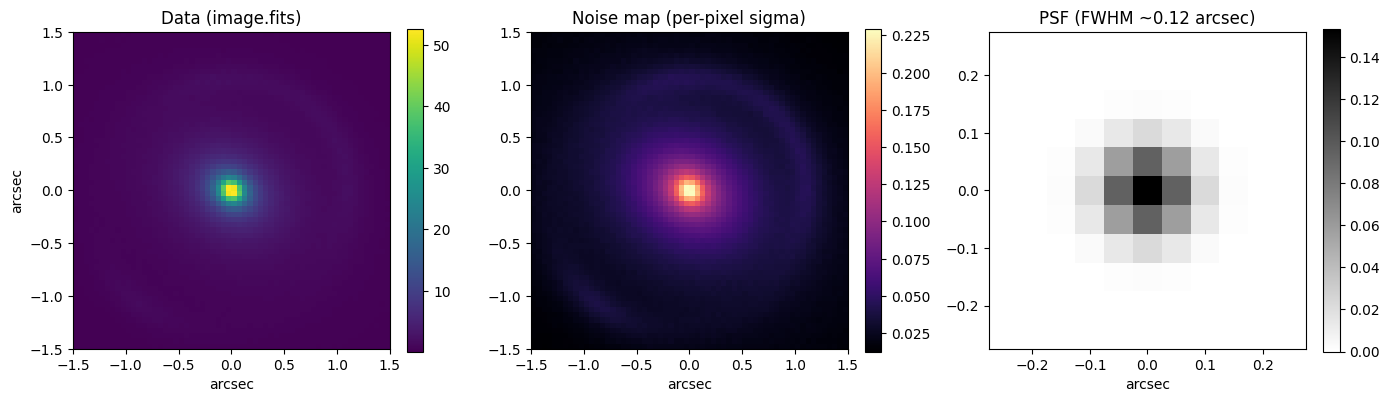

masked pixels: 3600


In [2]:
import matplotlib.pyplot as plt
import numpy as np

mask = al.Mask2D.circular(
    shape_native=dataset.shape_native, pixel_scales=dataset.pixel_scales,
    radius=2.5,
)
masked = dataset.apply_mask(mask=mask)

# Three-panel matplotlib view of data / noise / PSF (no aplt class dependency;
# autolens.plot in 2026.4 ships function-style helpers, not the ImagingPlotter class).
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
extent = [-1.5, 1.5, -1.5, 1.5]
im0 = axes[0].imshow(np.array(dataset.data.native), origin='lower', cmap='viridis', extent=extent)
axes[0].set_title('Data (image.fits)'); axes[0].set_xlabel('arcsec'); axes[0].set_ylabel('arcsec')
plt.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(np.array(dataset.noise_map.native), origin='lower', cmap='magma', extent=extent)
axes[1].set_title('Noise map (per-pixel sigma)'); axes[1].set_xlabel('arcsec')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
# In autolens 2026.4 dataset.psf is a Convolver; the kernel array is .kernel.native
psf_arr = np.array(dataset.psf.kernel.native)
half = psf_arr.shape[0] * dataset.pixel_scales[0] / 2
im2 = axes[2].imshow(psf_arr, origin='lower', cmap='gray_r', extent=[-half, half, -half, half])
axes[2].set_title('PSF (FWHM ~0.12 arcsec)'); axes[2].set_xlabel('arcsec')
plt.colorbar(im2, ax=axes[2], fraction=0.046)
plt.tight_layout(); plt.show()
print(f'masked pixels: {masked.mask.pixels_in_mask}')

## 3. The model

The driver `fit_example_galaxy_galaxy_single_arc.py` builds two variants:

**`--part=direct`** — wide uninformative priors. 12 free params. Demonstrates what "first principles" Nautilus exploration looks like.

```python
lens   = Galaxy(redshift=0.3,
                bulge=lp.Sersic(centre=Gauss(0, σ=0.3), intensity=U(0,5),
                                R_e=U(0.3, 3.0), n=U(2, 6), ell=...),
                mass =mp.Isothermal(centre=tied, θ_E=U(0.5, 2.5), ell=...),
                shear=mp.ExternalShear(γ₁=Gauss(0, σ=0.05), γ₂=Gauss(0, σ=0.05)))
source = Galaxy(redshift=1.0,
                bulge=lp.Sersic(centre=Gauss(0, σ=0.3), intensity=U(0,2),
                                R_e=U(0.05, 0.5), n=U(0.5, 4), ell=...))
```

**`--part=truth_anchored`** — tight Gaussians anchored on truth values. Same physical model. Used for chi²-at-truth diagnostic baseline.

Cannon: `sbatch --time=4:00:00 --mem=192G --cpus-per-task=32 --account=siag_lab --partition=siag --job-name=ggsa_direct --export=ALL,EXAMPLE=galaxy_galaxy_single_arc,FIT_EXTRA_ARGS='--part=direct' submit_cannon.slurm`. Wall ~2 h on 32 cores.

**Memory note.** This fit OOM'd at 64 GB and 128 GB — Nautilus's 32 worker processes each load an autolens runtime + dataset, and the post-process export step exports all 45+ fits in `output/`. The 2026-05-11 memory-budgeting rule applies: **--mem=192 GB minimum on 32 cores for any single-galaxy autolens fit.**

## 4. Read the result

When the Cannon fit lands, the export pipeline writes `Examples/galaxy_galaxy_single_arc/results/ggsa_direct/`. If absent, this cell is informational — re-run after pulling.

In [3]:
summary_path = RESULTS / 'ggsa_direct' / 'summary.json'
if summary_path.exists():
    s = json.loads(summary_path.read_text())
    print(f'log_evidence:                 {s["log_evidence"]:.2f}')
    print(f'chi2/N:                       {s["chi_squared_per_pixel"]:.3f}')
    print(f'max |normalized residual|:   {s["max_abs_normalized_residual"]:.2f} sigma')
    print(f'n unmasked pixels:           {s["n_unmasked_pixels"]}')
    # Strict-PASS bar (cluster_scale calibrated): chi2/N <= 1.3, max <= 4.1 sigma
    if s['chi_squared_per_pixel'] <= 1.3 and s['max_abs_normalized_residual'] <= 4.1:
        print('\nVerdict: STRICT-PASS')
    elif s['max_abs_normalized_residual'] <= 6.0:
        print('\nVerdict: borderline-PASS (open fit_subplot.png to confirm white-noise residual)')
    else:
        print('\nVerdict: SUSPECT — open fit_subplot.png to identify Pattern A-F')
else:
    print(f'No result yet at {summary_path.relative_to(REPO)}.')
    print(f'Run the Cannon fit + pull, then re-execute this cell.')

No result yet at Examples/galaxy_galaxy_single_arc/results/ggsa_direct/summary.json.
Run the Cannon fit + pull, then re-execute this cell.


## 5. The 6-panel residual walk (Module 11)

If the fit lands, the canonical first thing to do is read its `fit_subplot.png` panel-by-panel. Module 11's six panels are:

1. **Data** — does it look like the input you expected?
2. **Model** — does the model image reproduce the data's gross features (ring shape, lens-light core)?
3. **Residual** — image minus model. Is it white noise?
4. **Normalised residual** — residual divided by noise map; > 4σ structure is a problem.
5. **Chi-squared map** — squared residual divided by noise²; where in the field does the model fail?
6. **Source plane** — what did the model think the source looked like? Does it match truth (Sersic n=1)?

For the canonical SLACS-style setup, expected patterns:
- A truth-anchored fit gives white-noise residual at max|res| ≈ 4σ (Bonferroni-corrected noise floor for ~5000 pixels).
- A direct fit with wide priors gives a near-identical residual with somewhat wider posterior tails.
- Pattern A (rotational mirror-image solutions) is the main risk — Isothermal lens models have a 180°-degenerate ellipticity sign. Multi-modal Nautilus posterior on (ell_comps_0, ell_comps_1) is the signature.

## 6. Recovering γ′ and θ_E from the posterior

The Isothermal mass profile is γ′ = 2 by construction (the *isothermal* slope). To recover γ′ *as a free parameter*, swap `mp.Isothermal` for `mp.PowerLaw` in the model — that's the SLACS Auger+10 / SL2S Sonnenfeld+13 measurement. On this canonical mock, γ′ should recover at 2.0 ± ~0.05 (truth, by construction).

On a real lens, γ′ posteriors from SLACS-style fits typically span 1.8–2.3, sometimes correlated with halo mass. Sonnenfeld+13 finds γ′_avg = 2.08 ± 0.02 across SL2S — slightly super-isothermal.

**θ_E posterior** should be tight (~0.005″ for SLACS-class data) and unambiguous — the Einstein-ring radius is the most-constrained quantity any lens model produces.

## 7. Exercises

1. **Free the mass slope.** Replace `mp.Isothermal` with `mp.PowerLaw` (`slope` becomes free). Run a second fit. Compare γ′ posterior to truth (2.0).
2. **Shear marginalisation.** Run a third fit with `shear` fixed at (0, 0). What happens to the (θ_E, ell_comps) posterior? — demonstrates shear's role as a marginalisation tool.
3. **Mass-follows-light coupling.** Currently `mass.centre = bulge.centre` (tied). Free the mass centre. The fit should pick mass-follows-light from the data alone — but with what σ?
4. **Source size / Einstein radius degeneracy.** Plot the joint posterior on (`source.effective_radius`, `lens.einstein_radius`). There's a classic degeneracy — at fixed magnification, a larger source can compensate for a smaller θ_E.
5. **Pattern A demonstration.** Pin `lens.bulge.sersic_index = 4.0` and rerun. With more freedom in `ell_comps`, can you find the 180°-rotated mirror solution? Plot both posteriors.

## Next stops

- **`Examples/compound_lens/`** — same setup + a secondary deflector
- **`Examples/mge_to_physical/`** — same setup + MGE light + stars+dark decomposition
- **`Examples/double_source_plane/`** — same setup + a second source plane (DSPL cosmography)
- **`Examples/quad_time_delay/`** — same setup + a point-source + time delays (TDCOSMO)
- **Module 11** — the 6-panel residual audit framework applied to all of the above